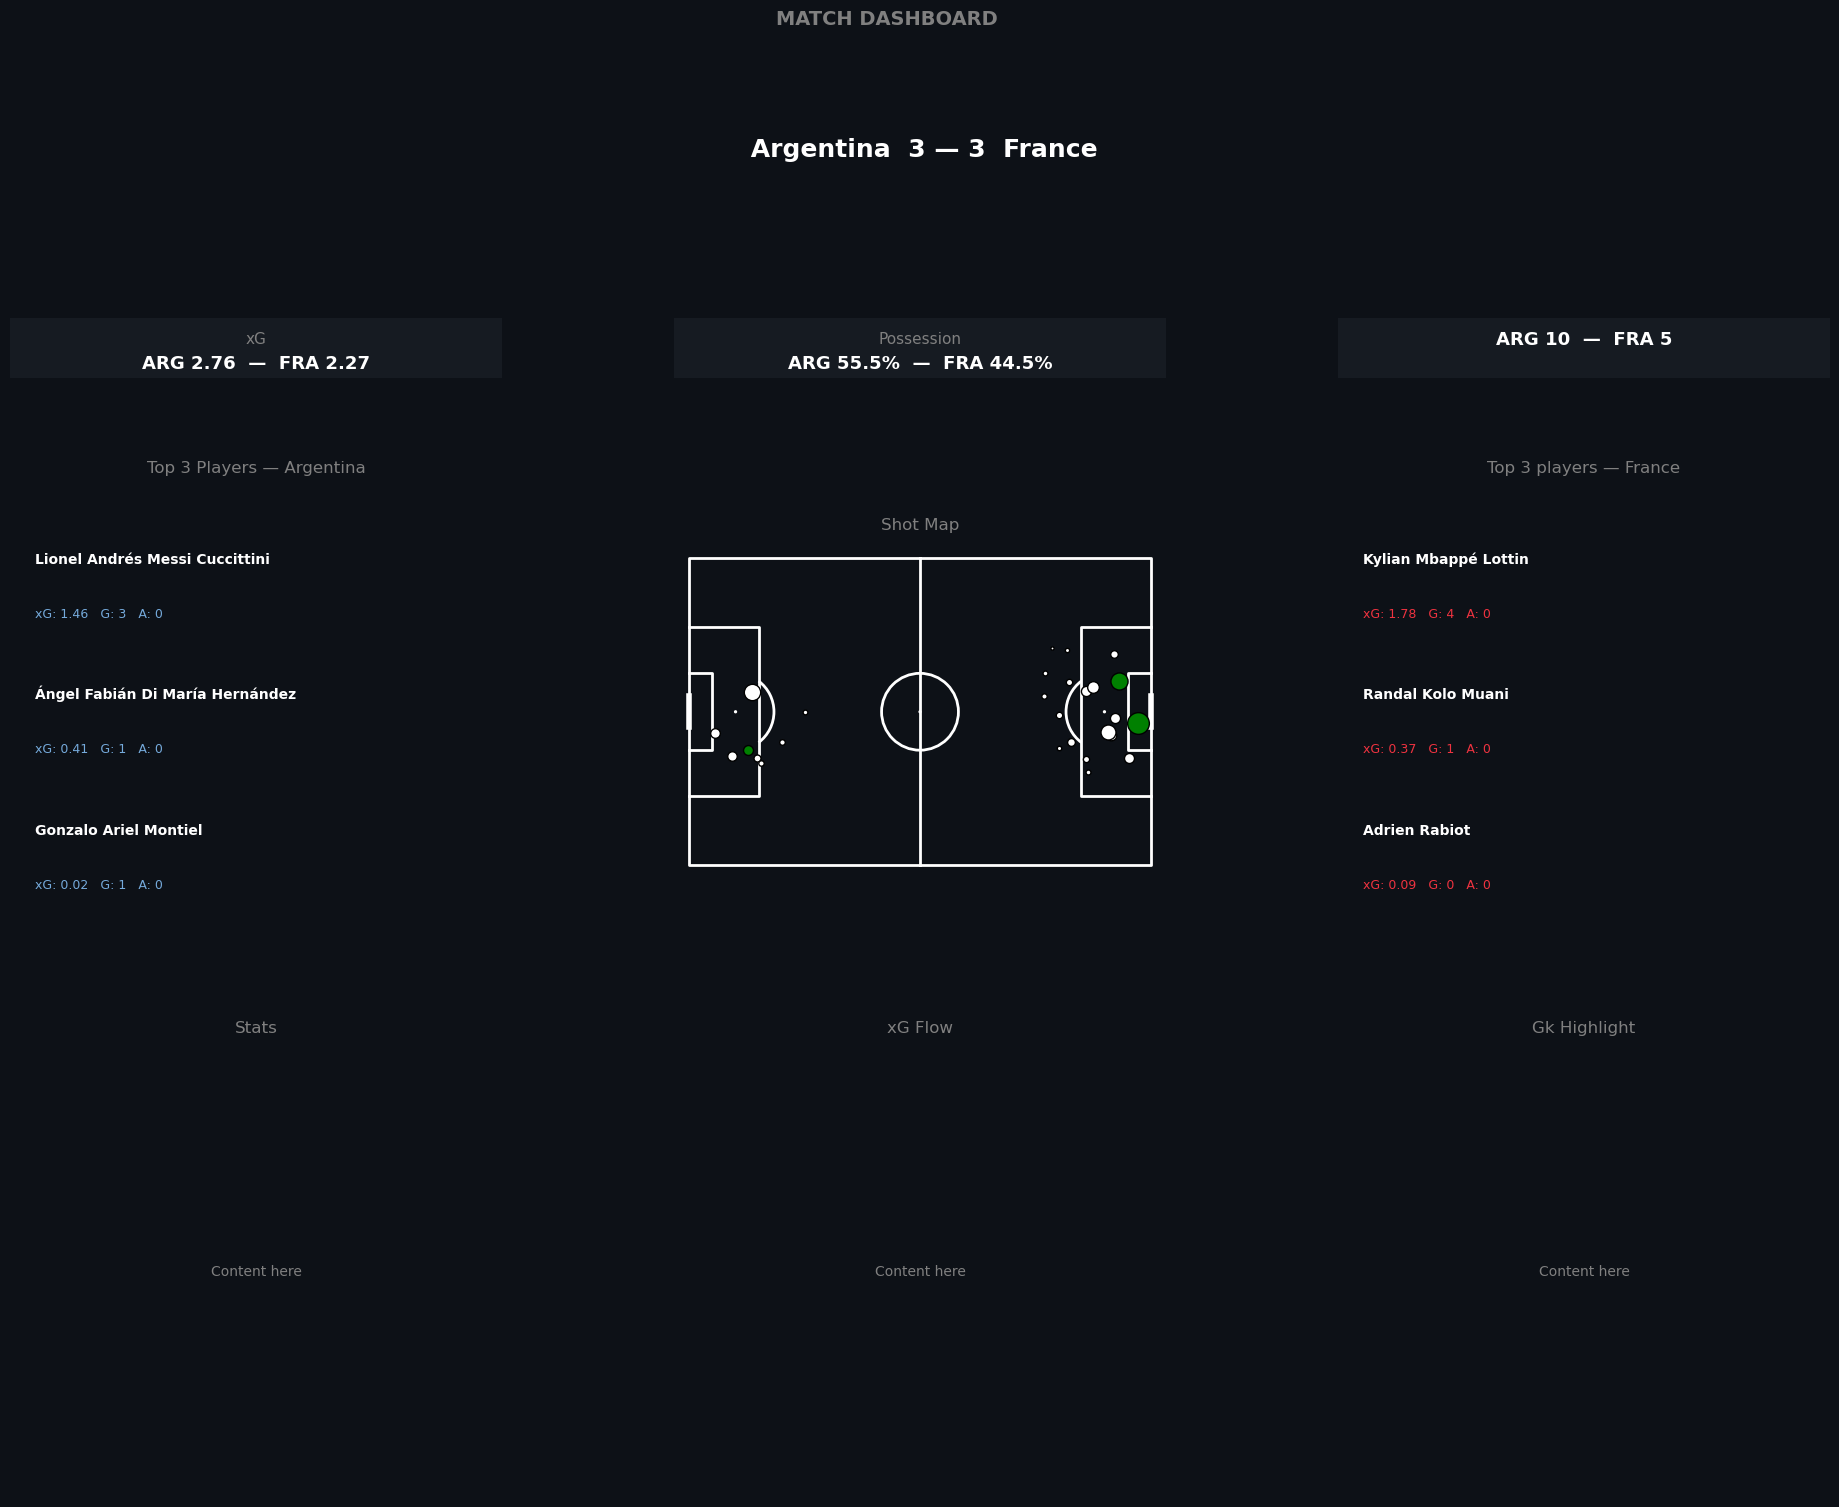

Template ready.


In [102]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd 
from statsbombpy import sb 
 # bch n7ather el xg 
shots = events[events['type'] == 'Shot']
shots = shots[shots['period'] != 5]
xg = shots.groupby('team')['shot_statsbomb_xg'].sum().round(2)
 # bch n7ather el game possesion  
possession = events[events['period'] != 5].groupby('possession_team')['id'].count()
possession_pct = (possession / possession.sum() * 100).round(1)
 # bch n7ather el shots on target 
shots_on_target = shots[shots['shot_outcome'].isin(['Goal', 'Saved'])].groupby('team')['id'].count()

def get_top3(events, team):

    # ── Filter shots, exclude shootout ──────────────
    shots = events[events['type'] == 'Shot']
    shots = shots[shots['period'] != 5]

    # ── xG per player ────────────────────────────────
    player_xg = shots.groupby(['team', 'player'])['shot_statsbomb_xg'].sum().round(2).reset_index()
    player_xg.columns = ['team', 'player', 'xg']

    # ── Goals per player ─────────────────────────────
    goals = events[events['shot_outcome'] == 'Goal'].groupby(['team', 'player'])['id'].count().reset_index()
    goals.columns = ['team', 'player', 'goals']

    # ── Assists per player ───────────────────────────
    assists = events[events['pass_goal_assist'] == True].groupby(['team', 'player'])['id'].count().reset_index()
    assists.columns = ['team', 'player', 'assists']

    # ── Combine ──────────────────────────────────────
    top_players = player_xg.merge(goals, on=['team', 'player'], how='left')
    top_players = top_players.merge(assists, on=['team', 'player'], how='left')
    top_players = top_players.fillna(0)

    # ── Filter to one team only ──────────────────────
    top_players = top_players[top_players['team'] == team]

    # ── Sort and return top 3 ────────────────────────
    top3 = top_players.sort_values(['goals', 'xg'], ascending=False).head(3).reset_index(drop=True)

    return top3


def plot_shotmap(events, team1, team2, ax):
    
    # ── Prepare data ────────────────────────────────
    df = events.copy()
    df = df[df["type"] == "Shot"]
    df = df[["team", "player", "shot_outcome", "shot_statsbomb_xg", "location", "shot_type"]]
    df = df[df["shot_type"] != "Penalty"]
    df['x'] = df['location'].apply(lambda loc: loc[0])
    df['y'] = df['location'].apply(lambda loc: loc[1])

    # ── Draw pitch ───────────────────────────────────
    pitch = Pitch(pitch_type="statsbomb", pitch_color='#0d1117', line_color='white')
    pitch.draw(ax=ax)

    # ── Plot shots ───────────────────────────────────
    for shot in df.to_dict(orient="records"):
        if shot["team"] == team2:
            pitch.scatter(x=120 - shot['x'], y=80 - shot['y'],
                          ax=ax, s=500 * shot["shot_statsbomb_xg"],
                          ec="black", c="green" if shot["shot_outcome"] == "Goal" else "white")
        else:
            pitch.scatter(x=shot['x'], y=shot['y'],
                          ax=ax, s=500 * shot["shot_statsbomb_xg"],
                          ec="black", c="green" if shot["shot_outcome"] == "Goal" else "white")


plt.style.use('dark_background')

fig = plt.figure(figsize=(20, 16), facecolor='#0d1117')

gs = GridSpec(
    4, 3,
    figure=fig,
    height_ratios=[0.8, 0.4, 3, 3],
    hspace=0.4,
    wspace=0.35,
    top=0.93,
    bottom=0.05,
    left=0.06,
    right=0.97
)

# ── ROW 0 — HEADER ──────────────────────────────────────────
ax_header = fig.add_subplot(gs[0, :])
ax_header.set_facecolor('#0d1117')
ax_header.set_xticks([])
ax_header.set_yticks([])
for spine in ax_header.spines.values():
    spine.set_visible(False)
ax_header.text(0.5, 0.5, ' Argentina  3 — 3  France',
               ha='center', va='center', fontsize=18,
               color='white', fontweight='bold',
               transform=ax_header.transAxes)

# ── ROW 1 — 3 STAT BOXES ────────────────────────────────────
ax_stat1 = fig.add_subplot(gs[1, 0])
ax_stat1.set_facecolor('#161b22')
ax_stat1.set_xticks([])
ax_stat1.set_yticks([])
for spine in ax_stat1.spines.values():
    spine.set_visible(False)
ax_stat1.text(0.5, 0.65, 'xG',
              ha='center', va='center', fontsize=11,
              color='gray', transform=ax_stat1.transAxes)
ax_stat1.text(0.5, 0.25, f"ARG {xg["Argentina"]}  —  FRA {xg["France"]}",
              ha='center', va='center', fontsize=13,
              color='white', fontweight='bold',
              transform=ax_stat1.transAxes)

ax_stat2 = fig.add_subplot(gs[1, 1])
ax_stat2.set_facecolor('#161b22')
ax_stat2.set_xticks([])
ax_stat2.set_yticks([])
for spine in ax_stat2.spines.values():
    spine.set_visible(False)
ax_stat2.text(0.5, 0.65, 'Possession',
              ha='center', va='center', fontsize=11,
              color='gray', transform=ax_stat2.transAxes)
ax_stat2.text(0.5, 0.25, f"ARG {possession_pct['Argentina']}%  —  FRA {possession_pct['France']}%",
              ha='center', va='center', fontsize=13,
              color='white', fontweight='bold',
              transform=ax_stat2.transAxes)

ax_stat3 = fig.add_subplot(gs[1, 2])
ax_stat3.set_facecolor('#161b22')
ax_stat3.set_xticks([])
ax_stat3.set_yticks([])
for spine in ax_stat3.spines.values():
    spine.set_visible(False)
ax_stat3.text(0.5, 0.65,  f"ARG {shots_on_target['Argentina']}  —  FRA {shots_on_target['France']}",
              ha='center', va='center', fontsize=13,
              color='white', fontweight='bold',
              transform=ax_stat3.transAxes)

# ── ROW 2 — TOP PLAYERS LEFT | MAIN VIZ | TOP PLAYERS RIGHT ─
ax_left = fig.add_subplot(gs[2, 0])
ax_left.set_facecolor('#0d1117')
ax_left.set_xticks([])
ax_left.set_yticks([])
for spine in ax_left.spines.values():
    spine.set_visible(False)
ax_left.set_title('Top 3 Players — Argentina', color='gray', fontsize=12, pad=10)
top3_arg = get_top3(events, 'Argentina')
positions = [0.75, 0.45, 0.15]

for i, row in top3_arg.iterrows():
    ax_left.text(0.05, positions[i] + 0.08, row['player'],
                 color='white', fontsize=10, fontweight='bold',
                 transform=ax_left.transAxes)
    ax_left.text(0.05, positions[i] - 0.04,
                 f"xG: {row['xg']}   G: {int(row['goals'])}   A: {int(row['assists'])}",
                 color='#75AADB', fontsize=9,
                 transform=ax_left.transAxes)

ax_center = fig.add_subplot(gs[2, 1])
ax_center.set_facecolor('#0d1117')
ax_center.set_xticks([])
ax_center.set_yticks([])
for spine in ax_center.spines.values():
    spine.set_visible(False)
ax_center.set_title('Shot Map', color='gray', fontsize=12, pad=10)
plot_shotmap(events, team1='Argentina', team2='France', ax=ax_center)


ax_right = fig.add_subplot(gs[2, 2])
ax_right.set_facecolor('#0d1117')
ax_right.set_xticks([])
ax_right.set_yticks([])
for spine in ax_right.spines.values():
    spine.set_visible(False)
ax_right.set_title('Top 3 players — France', color='gray', fontsize=12, pad=10)
top3_fra = get_top3(events, 'France')

for i, row in top3_fra.iterrows():
    ax_right.text(0.05, positions[i] + 0.08, row['player'],
                  color='white', fontsize=10, fontweight='bold',
                  transform=ax_right.transAxes)
    ax_right.text(0.05, positions[i] - 0.04,
                  f"xG: {row['xg']}   G: {int(row['goals'])}   A: {int(row['assists'])}",
                  color='#EF3340', fontsize=9,
                  transform=ax_right.transAxes)

# ── ROW 3 — SECTION A | SECTION B | SECTION C ───────────────
ax_bottom_left = fig.add_subplot(gs[3, 0])
ax_bottom_left.set_facecolor('#0d1117')
ax_bottom_left.set_xticks([])
ax_bottom_left.set_yticks([])
for spine in ax_bottom_left.spines.values():
    spine.set_visible(False)
ax_bottom_left.set_title('Stats', color='gray', fontsize=12, pad=10)
ax_bottom_left.text(0.5, 0.5, 'Content here',
                    ha='center', va='center', fontsize=10,
                    color='gray', transform=ax_bottom_left.transAxes)

ax_bottom_center = fig.add_subplot(gs[3, 1])
ax_bottom_center.set_facecolor('#0d1117')
ax_bottom_center.set_xticks([])
ax_bottom_center.set_yticks([])
for spine in ax_bottom_center.spines.values():
    spine.set_visible(False)
ax_bottom_center.set_title('xG Flow', color='gray', fontsize=12, pad=10)
ax_bottom_center.text(0.5, 0.5, 'Content here',
                      ha='center', va='center', fontsize=10,
                      color='gray', transform=ax_bottom_center.transAxes)

ax_bottom_right = fig.add_subplot(gs[3, 2])
ax_bottom_right.set_facecolor('#0d1117')
ax_bottom_right.set_xticks([])
ax_bottom_right.set_yticks([])
for spine in ax_bottom_right.spines.values():
    spine.set_visible(False)
ax_bottom_right.set_title('Gk Highlight', color='gray', fontsize=12, pad=10)
ax_bottom_right.text(0.5, 0.5, 'Content here',
                     ha='center', va='center', fontsize=10,
                     color='gray', transform=ax_bottom_right.transAxes)

# ── Main title ───────────────────────────────────────────────
fig.suptitle('MATCH DASHBOARD ',
             fontsize=14, color='gray',
             fontweight='bold', y=0.98)

plt.savefig('dashboard_template.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Template ready.")